#### Importing Required Libararies:

In [21]:
import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#### Loading data and preprocessor:

In [3]:
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

preprocessor = joblib.load("../outputs/models/preprocessor.pkl")

# Application and Evaluation of different ML models:

## 1. Random Forest Algorithm:

#### Initialization of pipeline:

In [4]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

#### Cross Validation

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy","precision","recall","f1","roc_auc"],
    n_jobs=-1)

#### Fold-wise scores:

In [10]:
results = pd.DataFrame(cv_results)
results

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,1.363147,0.137867,0.989011,1.000000,0.982759,0.991304,0.999739
1,1.264820,0.134063,0.945055,0.948276,0.964912,0.956522,0.983488
2,1.357515,0.136587,0.934066,1.000000,0.894737,0.944444,0.985294
3,1.022396,0.063425,0.923077,0.962963,0.912281,0.936937,0.979876
4,0.501765,0.065776,0.989011,1.000000,0.982456,0.991150,0.999484


#### Average Cross Validation Results:

In [15]:
results.mean()

fit_time          1.101929
score_time        0.107544
test_accuracy     0.956044
test_precision    0.982248
test_recall       0.947429
test_f1           0.964072
test_roc_auc      0.989576
dtype: float64

#### Standard Deviation between the folds:

This is for looking that how much the performance of the model varies between the folds.

In [16]:
results.std()

fit_time          0.362841
score_time        0.039234
test_accuracy     0.031082
test_precision    0.024857
test_recall       0.041209
test_f1           0.025756
test_roc_auc      0.009367
dtype: float64

#### Training on entire training data:

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['mean radius',
                                                   'mean texture',
                                                   'mean perimeter',
                                                   'mean area',
                                                   'mean smoothness',
                                                   'mean compactness',
                                                   'mean concavity',
                                                   'mean concave points',
                                                   'mean symmetry',
                                                   'mean fractal dimension',
                                                   'radius error',
                                                   'texture error',
                                                   'perimeter error',
                                                   'area error',
                                                   'smoothness er...
                                                   'compactness error',
                                                   'concavity error',
                                                   'concave points error',
                                                   'symmetry error',
                                                   'fractal dimension error',
                                                   'worst radius',
                                                   'worst texture',
                                                   'worst perimeter',
                                                   'worst area',
                                                   'worst smoothness',
                                                   'worst compactness',
                                                   'worst concavity',
                                                   'worst concave points',
                                                   'worst symmetry',
                                                   'worst fractal '
                                                   'dimension'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier(random_state=42))])

#### Predictions on Test Set:

In [18]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:, 1]

#### Test Metrics:

In [20]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9736842105263158
Precision: 0.9857142857142858
Recall   : 0.971830985915493
F1 Score : 0.9787234042553191
ROC AUC  : 0.9980347199475926


#### Confusion Matrix:

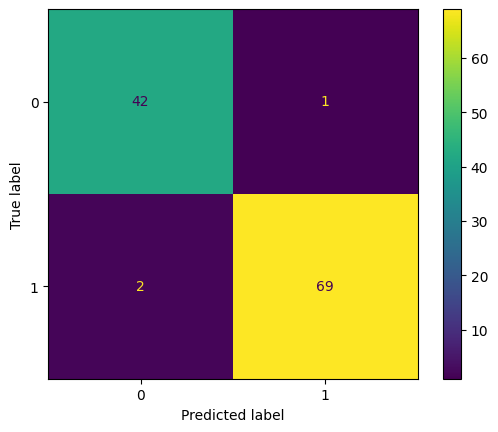

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

#### Compare Cross Validation vs Test:

Here, I am comparing the training and testing results to look for overfitting.

In [26]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "CV Mean": [
        results["test_accuracy"].mean(),
        results["test_precision"].mean(),
        results["test_recall"].mean(),
        results["test_f1"].mean(),
        results["test_roc_auc"].mean()
    ],
    "Test": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

comparison

,Metric,CV Mean,Test
0,Accuracy,0.956044,0.973684
1,Precision,0.982248,0.985714
2,Recall,0.947429,0.971831
3,F1,0.964072,0.978723
4,ROC-AUC,0.989576,0.998035


By looking at the comparison, I find out that there is no overfitting.

## 2. Logistic Regression: